In [2]:
# Import libraries
import numpy as np
import math
import pandas as pd
import os
# Import graphing libraries
import matplotlib.pyplot as plt
import seaborn as sns  # Theme
import pickle
from matplotlib.dates import DayLocator, MonthLocator, DateFormatter

In [11]:
# Import dataset
dataset = pd.read_csv("../data/mag7_stocks.csv")

# Check if data is loaded
print(dataset.head(), "\n")
dataset.info()

# Convert date datatype from object to datetime
dataset[dataset.columns[1]] = pd.to_datetime(dataset[dataset.columns[1]])
# dataset = dataset[dataset["Date"] < "2025-09-01"]
# dataset = dataset[dataset['Date'] < '2025-10-01']
dataset.info()

   Unnamed: 0        Date Ticker        Open        High         Low  \
0           0  2025-01-02   AAPL  248.929993  249.100006  241.820007   
1           1  2025-01-02   AAPL  248.929993  249.100006  241.820007   
2           2  2025-01-03   AAPL  243.360001  244.179993  241.889999   
3           3  2025-01-03   AAPL  243.360001  244.179993  241.889999   
4           4  2025-01-06   AAPL  244.309998  247.330002  243.199997   

        Close    Volume  
0  243.850006  55740700  
1  243.850006  55740700  
2  243.360001  40244100  
3  243.360001  40244100  
4  245.000000  45045600   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2310 entries, 0 to 2309
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2310 non-null   int64  
 1   Date        2310 non-null   object 
 2   Ticker      2310 non-null   object 
 3   Open        2310 non-null   float64
 4   High        2310 non-null   float64
 5   Low        

In [12]:
type(dataset["Date"].iloc[0])

pandas._libs.tslibs.timestamps.Timestamp

In [4]:
# Folder to place our matplotlib figures in
figures_folder_name = "figures"

In [5]:
# Show companies
companies = dataset["Ticker"].dropna().unique().tolist()
print(companies)

['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


In [6]:
# Identify column names from dataset
COL_DATE = "Date"
COL_NAME = "Ticker"
COL_OPEN = "Open"
COL_HIGH = "High"
COL_LOW = "Low"
COL_CLOSE = "Close"
COL_VOLUME = "Volume"

In [7]:
# Theme of graphs
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.frameon": True,
    "legend.framealpha": 1,
})

Companies found: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


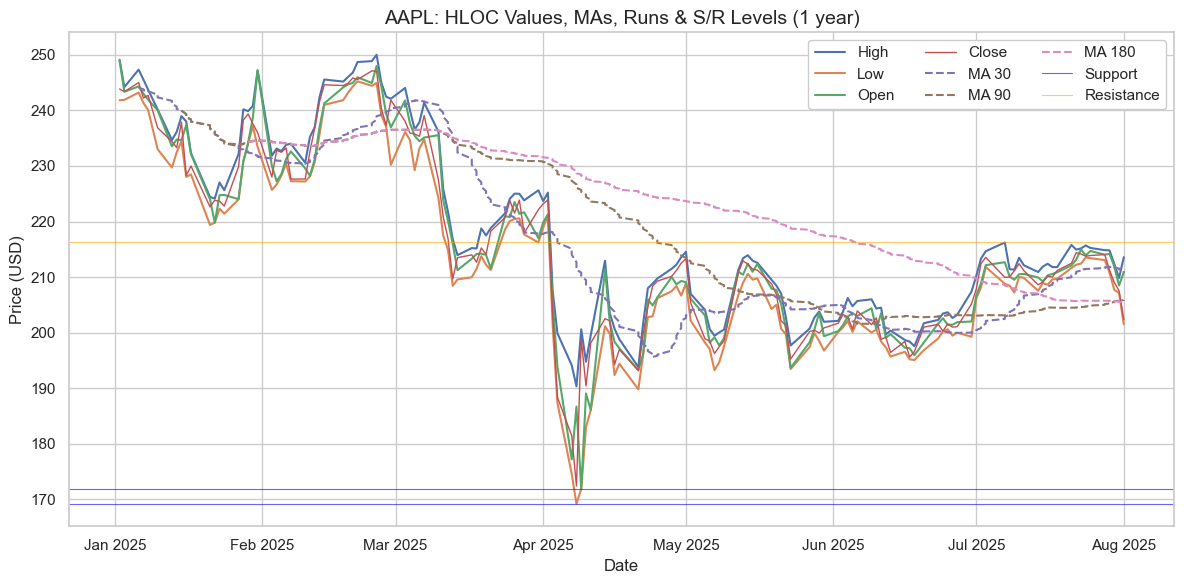

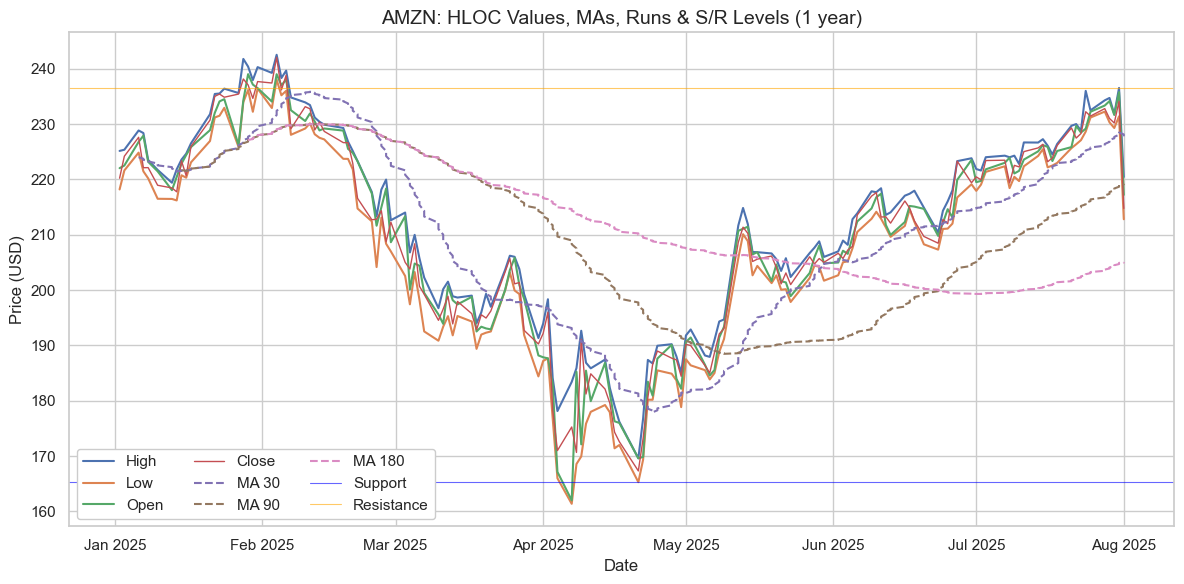

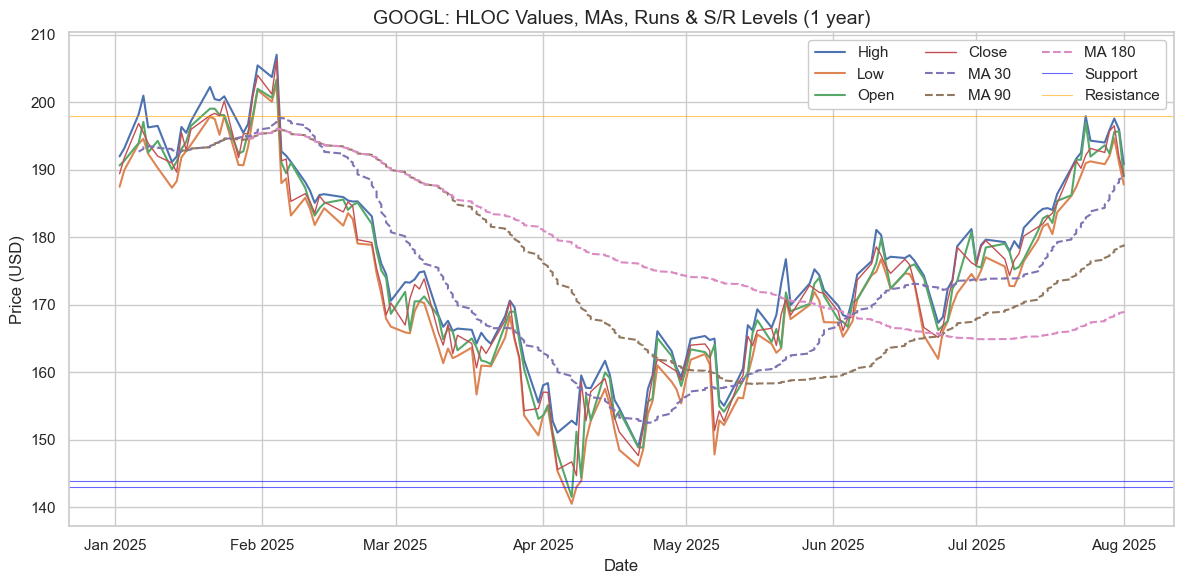

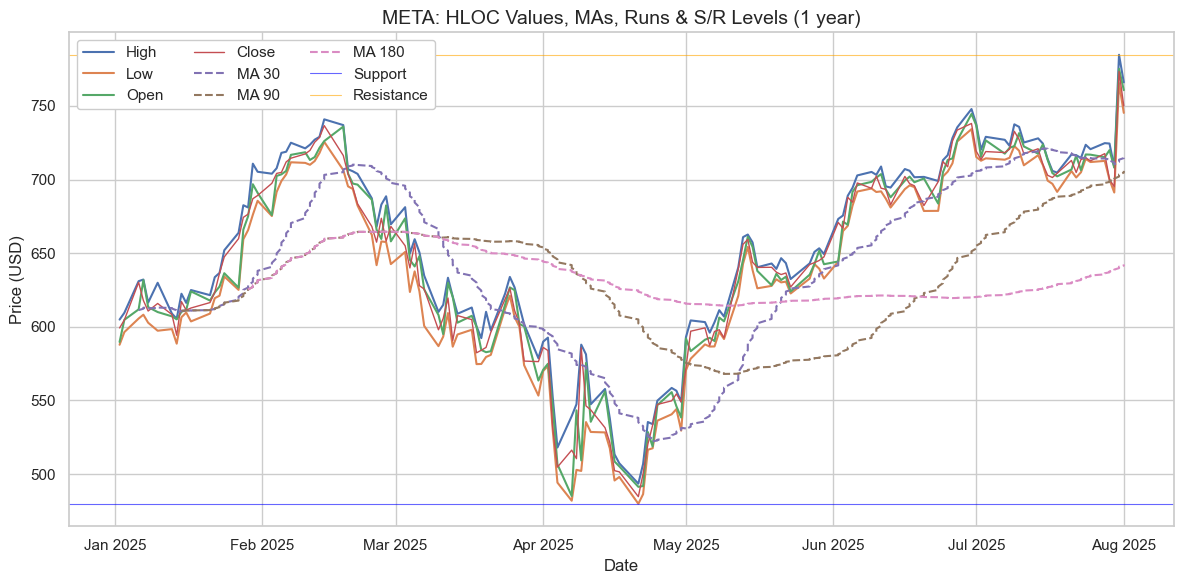

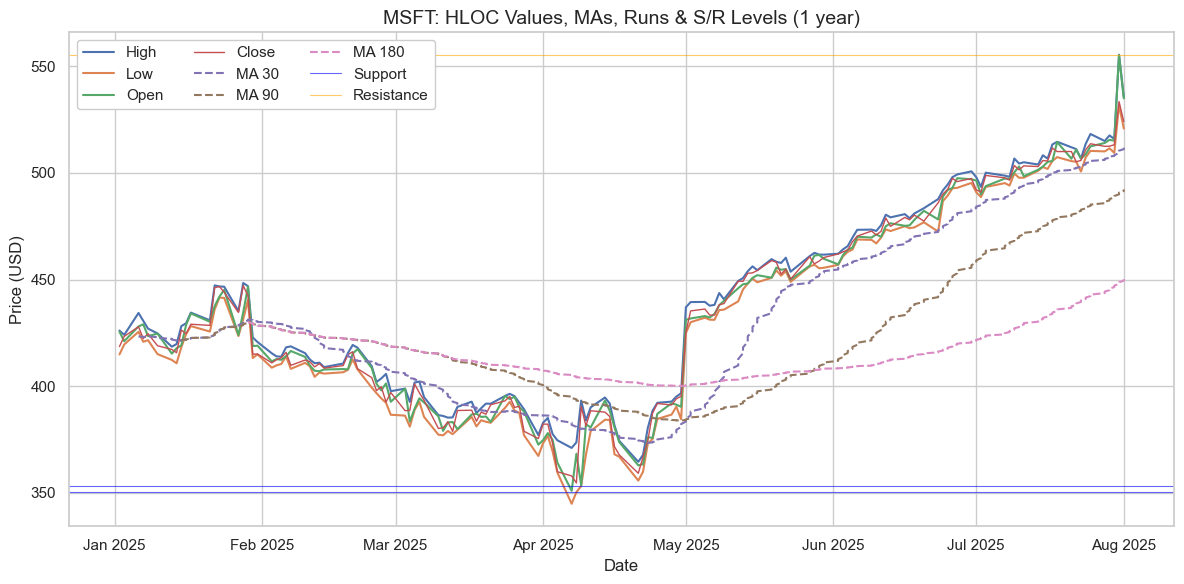

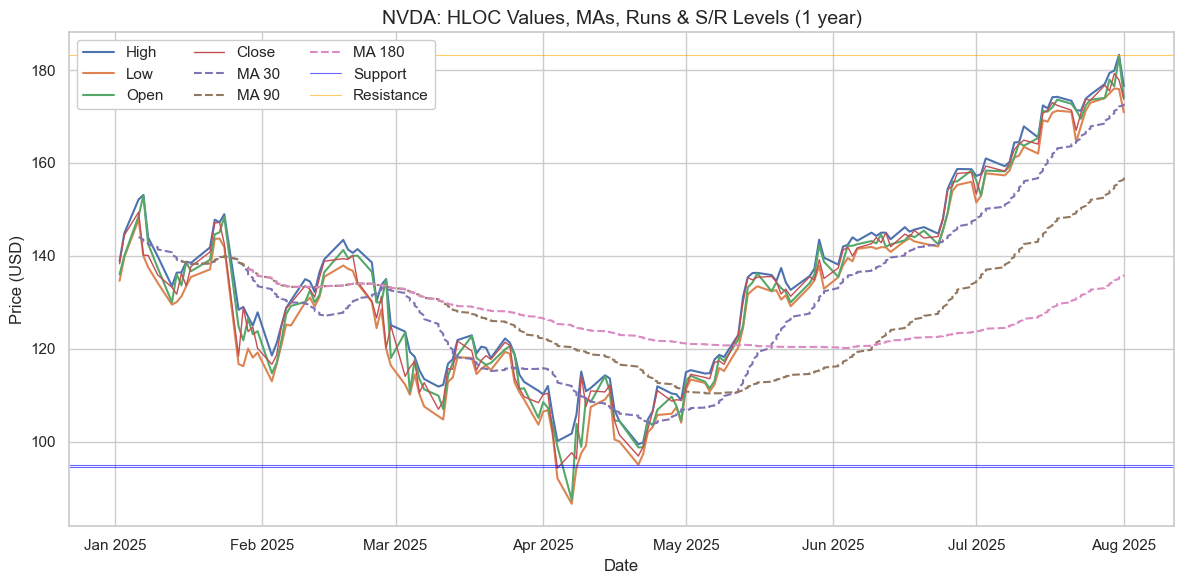

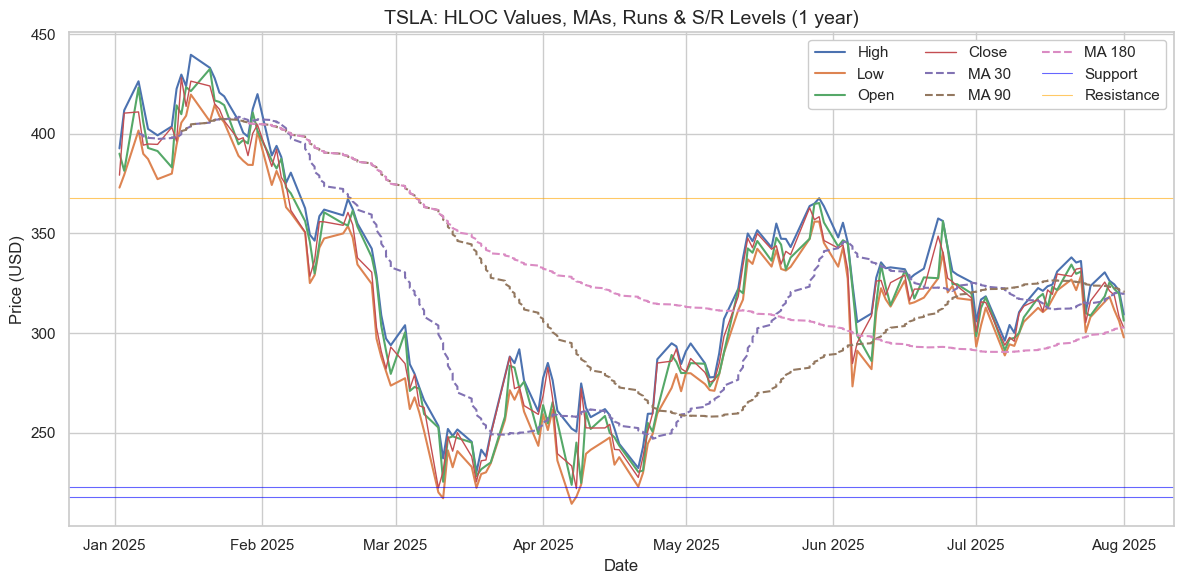

In [13]:

# List of companies
companies = dataset[COL_NAME].dropna().unique().tolist()
print("Companies found:", companies)

# --- Ask for global start/end dates once ---
start_date_str = input("Enter start date for all charts (YYYY-MM-DD): ")
end_date_str = input("Enter end date for all charts (YYYY-MM-DD): ")

start_date = pd.to_datetime(start_date_str)
end_date = pd.to_datetime(end_date_str)

# --- Plot for every company ---
for name in companies:

    # Split company data from dataset
    df = dataset[dataset[COL_NAME] == name]
    df = df.sort_values(by=COL_DATE)

    # Filter dataset using global dates
    df = df[(df[COL_DATE] >= start_date) & (df[COL_DATE] <= end_date)]

    # Skip empty datasets
    if df.empty:
        print(f"\n[WARNING] No data available for {name} between {start_date_str} and {end_date_str}.")
        continue

    # --- Recency setup ---
    recency_type = "years"  # Select: "days", "months", or "years"
    recency_value = 1
    last_date = df[COL_DATE].max()

    # Trim recent data for calculations
    if recency_type == "years":
        recent_start = last_date - pd.DateOffset(years=recency_value)
    elif recency_type == "months":
        recent_start = last_date - pd.DateOffset(months=recency_value)
    else:
        recent_start = last_date - pd.DateOffset(days=recency_value)

    df = df[df[COL_DATE] >= recent_start]

    # --- Moving Averages ---
    for win in (30, 90, 180):  # 1, 3, 6 months
        df[f"MA_{win}"] = df[COL_CLOSE].rolling(window=win, min_periods=max(5, win//5)).mean()

    # --- Upward/Downward Runs ---
    df["Close_Diff"] = df[COL_CLOSE].diff()
    df["Run"] = df["Close_Diff"].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
    df["Run_Group"] = (df["Run"] != df["Run"].shift()).cumsum()
    run_segments = df.groupby("Run_Group").filter(lambda x: len(x) >= 3)

    # --- Dynamic Support/Resistance Window ---
    if recency_type == "days":
        sr_window = 5
    elif recency_type == "months":
        sr_window = 20
    else:
        sr_window = 60

    # Calculate rolling support/resistance levels
    support = df[COL_LOW].rolling(window=sr_window, min_periods=1).min()
    resistance = df[COL_HIGH].rolling(window=sr_window, min_periods=1).max()

    # Pick key recent levels
    support_levels = support.tail(100).nsmallest(3).unique()
    resistance_levels = resistance.tail(100).nlargest(3).unique()

    # --- Plotting Section ---
    fig, ax = plt.subplots()
    ax.plot(df[COL_DATE], df[COL_HIGH], label="High")
    ax.plot(df[COL_DATE], df[COL_LOW], label="Low")
    ax.plot(df[COL_DATE], df[COL_OPEN], label="Open")
    ax.plot(df[COL_DATE], df[COL_CLOSE], label="Close", linewidth=1)

    # Plot moving averages
    for win in (30, 90, 180):
        ax.plot(df[COL_DATE], df[f"MA_{win}"], label=f"MA {win}", linestyle="--")

    # Plot support & resistance lines
    for level in support_levels:
        ax.axhline(y=level, color='blue', linestyle='-', linewidth=0.8, alpha=0.6,
                   label="Support" if "Support" not in ax.get_legend_handles_labels()[1] else "")
    for level in resistance_levels:
        ax.axhline(y=level, color='orange', linestyle='-', linewidth=0.8, alpha=0.6,
                   label="Resistance" if "Resistance" not in ax.get_legend_handles_labels()[1] else "")

    # Highlight upward/downward runs
    for _, group in run_segments.groupby("Run_Group"):
        color = 'green' if group["Run"].iloc[0] == 1 else 'red'
        ax.axvspan(group[COL_DATE].iloc[0], group[COL_DATE].iloc[-1], color=color, alpha=0.1)

    # --- X-axis Formatting ---
    if (recency_type == "days" and recency_value <= 31) or (
        recency_type == "months" and recency_value == 1):
        ax.xaxis.set_major_locator(DayLocator(interval=1))
        ax.xaxis.set_major_formatter(DateFormatter('%d'))
    elif recency_type == "years" and recency_value == 1:
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

    # --- Labels and Layout ---
    ax.set_title(f"{name}: HLOC Values, MAs, Runs & S/R Levels "
                 f"({recency_value} {recency_type[:-1] if recency_value == 1 else recency_type})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.show()
    print("\n")

    # Save the figure as a pickle file
    figures_folder_name = "figures"
    if not os.path.exists(figures_folder_name):
        os.makedirs(figures_folder_name)
    with open(f"{figures_folder_name}/{name}", "wb") as f:
        pickle.dump(fig, f)


In [93]:
from pathlib import Path


with open(Path.cwd().parent / "graphs" /  "figures" / "AAPL", "rb") as f:
    fig = pickle.load(f)

fig.axes[0].lines

<Axes.ArtistList of 10 lines>

In [53]:
fig.axes[0].lines

<Axes.ArtistList of 10 lines>